# Clase 2 · Análisis exploratorio de datos I

**Módulo 1: Introducción y fundamentos estadísticos** · Diplomado en Ciencia de Datos Aplicada · UTFSM

Objetivos de la sesión: describir una variable con sus tres miradas (centro, dispersión y forma) y revisar la calidad de los datos antes de analizarlos: faltantes, duplicados, valores sospechosos y merges verificados.

## 1. Preparación

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Gráficos más nítidos en pantallas de alta resolución
%config InlineBackend.figure_format = "retina"


In [2]:
BASE = (
    "https://raw.githubusercontent.com/daniopitz/diplomado-cdd/"
    "main/datos/eod_stgo/"
)
# Si clonó el repositorio del curso, los datos ya están en su disco:
# BASE = "datos/eod_stgo/"

viajes = pd.read_csv(BASE + "viajes.csv", sep=";", decimal=",", low_memory=False)
hogares = pd.read_csv(BASE + "Hogares.csv", sep=";", decimal=",", low_memory=False)

print(viajes.shape, hogares.shape)

(113591, 35) (18264, 21)


## 2. Tendencia central

Tres resúmenes del centro de una variable cuantitativa: la **media** (la suma dividida por el número de observaciones), la **mediana** (el valor que deja la mitad de los datos a cada lado) y la **moda** (el valor más frecuente).

In [3]:
tv = viajes["TiempoViaje"]

print("Media:  ", round(tv.mean(), 1), "minutos")
print("Mediana:", tv.median(), "minutos")
print("Moda:   ", tv.mode()[0], "minutos")

Media:   36.9 minutos
Mediana: 30.0 minutos
Moda:    30.0 minutos


Media 36,9 y mediana 30: no coinciden porque la distribución es asimétrica. El caso extremo es el ingreso de los hogares:

Media:   688274
Mediana: 507826


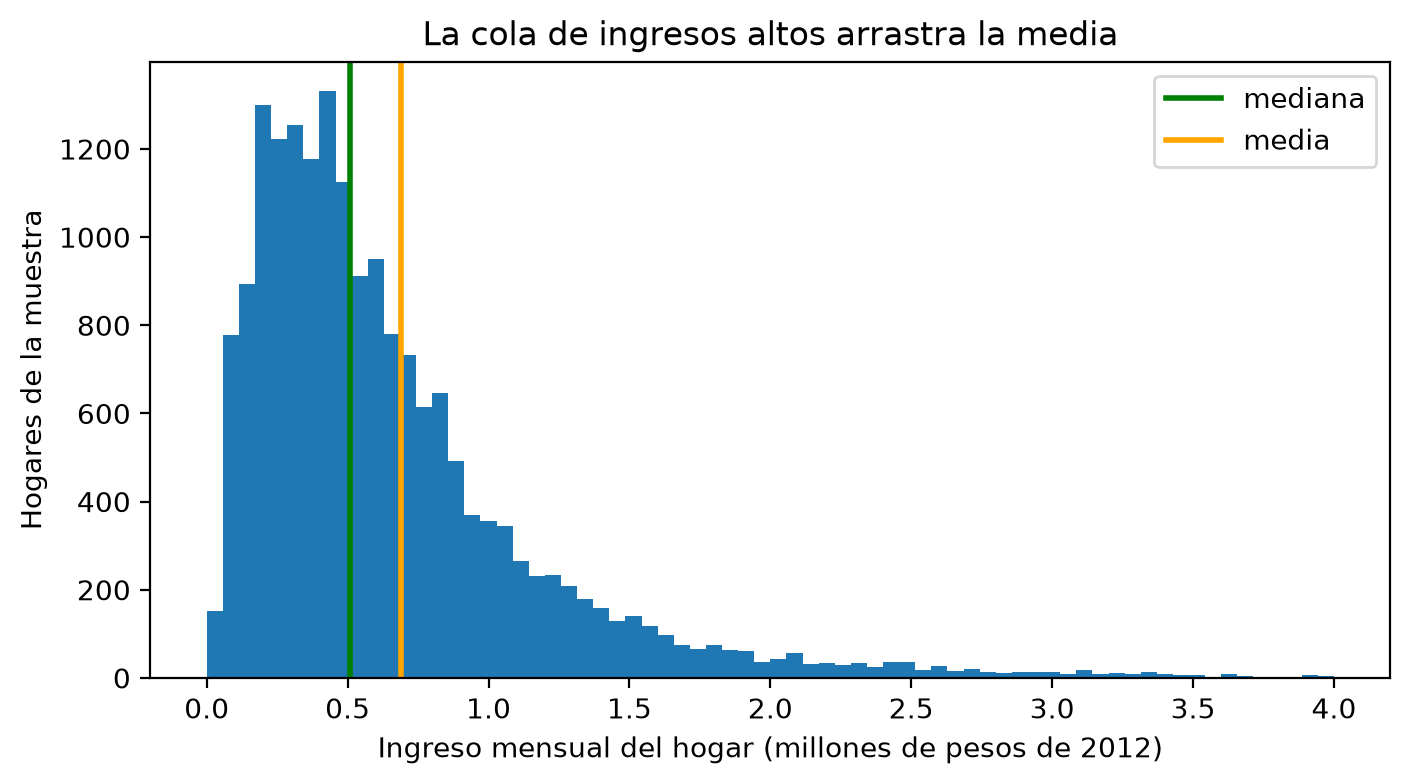

In [4]:
ingreso = hogares["IngresoHogar"]

print("Media:  ", round(ingreso.mean()))
print("Mediana:", round(ingreso.median()))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ingreso / 1e6, bins=70, range=(0, 4))
ax.axvline(ingreso.median() / 1e6, color="green", lw=2, label="mediana")
ax.axvline(ingreso.mean() / 1e6, color="orange", lw=2, label="media")
ax.set_xlabel("Ingreso mensual del hogar (millones de pesos de 2012)")
ax.set_ylabel("Hogares de la muestra")
ax.set_title("La cola de ingresos altos arrastra la media")
ax.legend()
plt.show()

La media queda 36% por sobre la mediana. Con distribuciones asimétricas (ingresos, duraciones, tamaños) se reportan ambas, o derechamente la mediana.

## 3. Dispersión

Cuánto varían los datos alrededor del centro: la **desviación estándar** (raíz de la varianza, en las unidades originales), los **percentiles** y el **rango intercuartílico** IQR = Q3 menos Q1, que concentra el 50% central.

In [5]:
print("Desviación estándar:", round(tv.std(), 1))
print("Mínimo y máximo:    ", tv.min(), "y", tv.max())
q1, q3 = tv.quantile(0.25), tv.quantile(0.75)
print("Q1, Q3, IQR:        ", q1, q3, q3 - q1)

Desviación estándar: 36.1
Mínimo y máximo:     0.0 y 1335.0
Q1, Q3, IQR:         15.0 50.0 35.0


Todo lo anterior, junto, es lo que entrega `describe`: ahora cada número tiene nombre y uso.

In [6]:
tv.describe().round(1)

count    113313.0
mean         36.9
std          36.1
min           0.0
25%          15.0
50%          30.0
75%          50.0
max        1335.0
Name: TiempoViaje, dtype: float64

## 4. Forma: histograma y boxplot

El histograma muestra la distribución completa; el **boxplot** la comprime en cinco números: mediana, cuartiles y bigotes (la convención de 1,5 veces el IQR marca los valores atípicos).

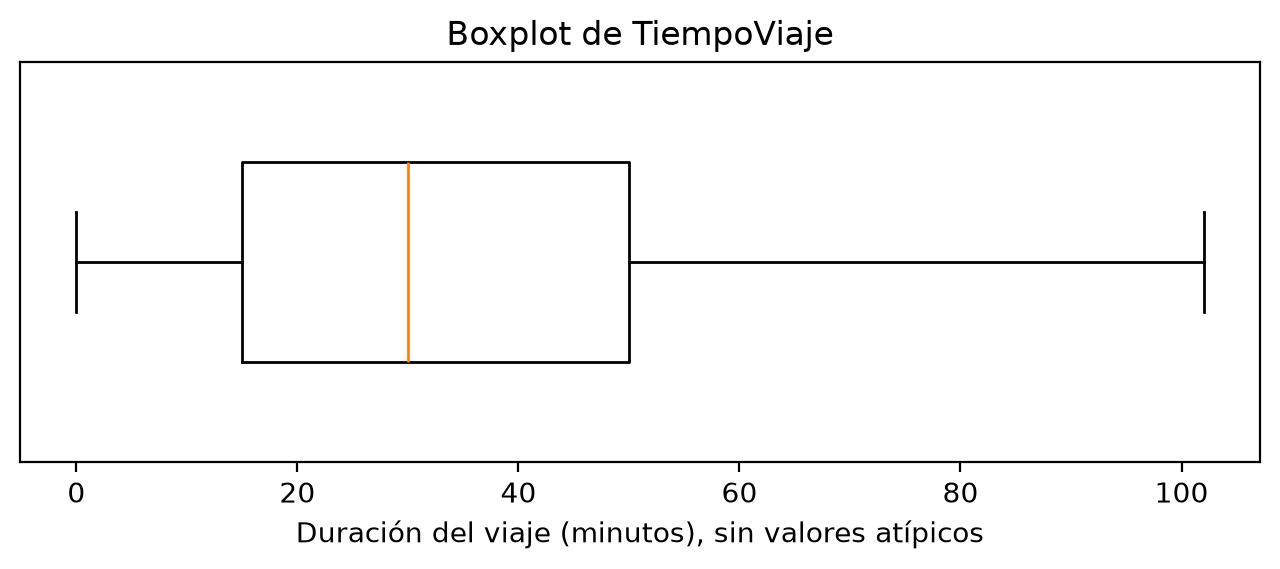

In [7]:
fig, ax = plt.subplots(figsize=(8, 2.6))
ax.boxplot(tv.dropna(), orientation="horizontal", showfliers=False, widths=0.5)
ax.set_yticks([])
ax.set_xlabel("Duración del viaje (minutos), sin valores atípicos")
ax.set_title("Boxplot de TiempoViaje")
plt.show()

El boxplot rinde al comparar grupos. Repasamos los merges de la clase 1 para traducir el modo de cada viaje y comparamos:

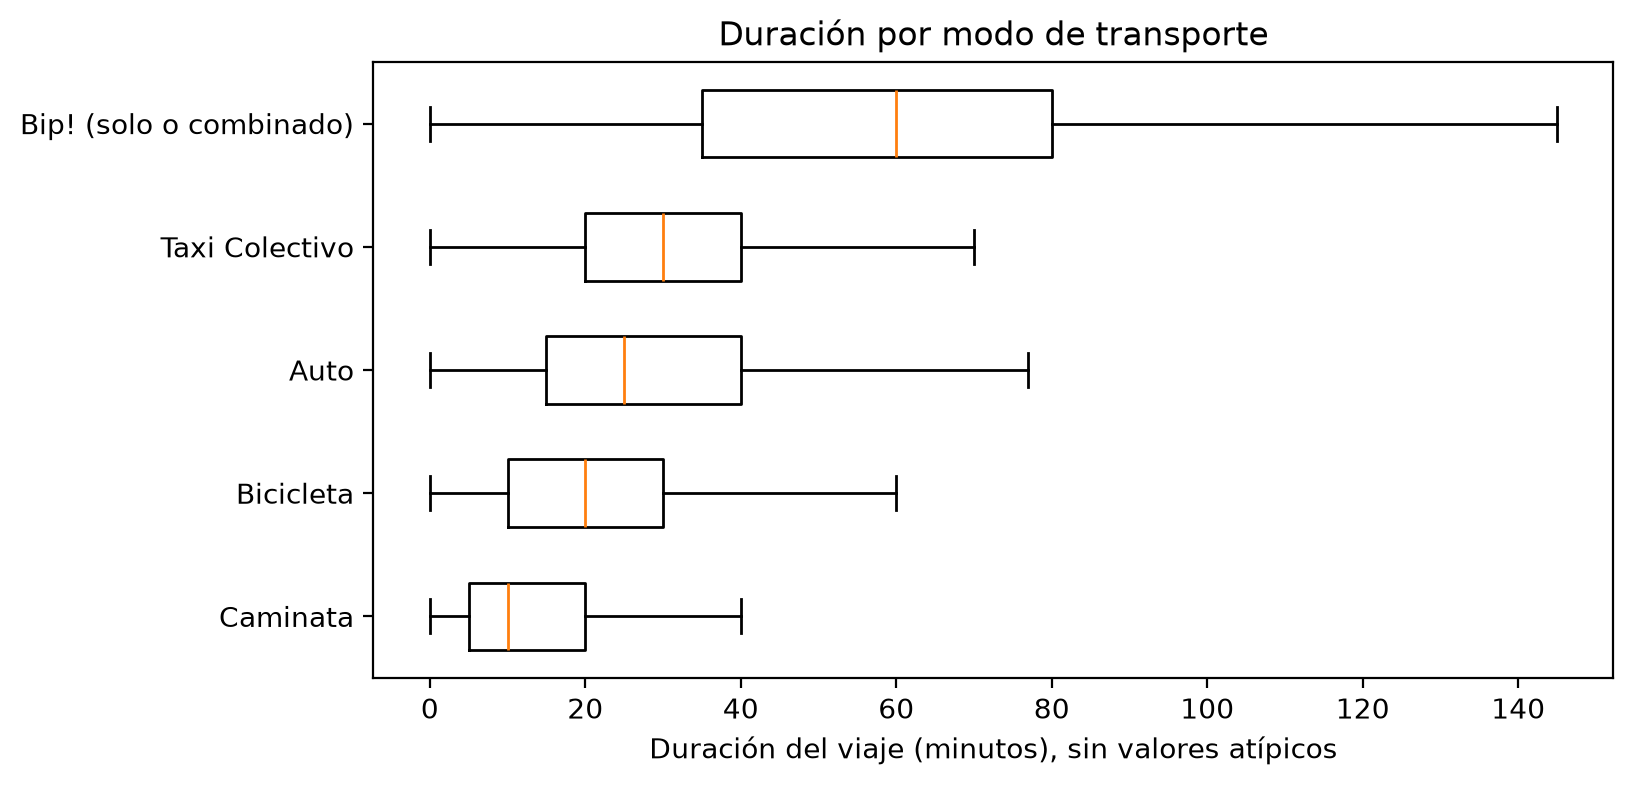

In [8]:
modo_por_viaje = pd.read_csv(BASE + "ViajesDifusion.csv", sep=";")
nombres_modo = pd.read_csv(BASE + "tablas_parametros/ModoDifusion.csv", sep=";")
nombres_modo = nombres_modo.rename(columns={"ModoDifusion": "NombreModo"})

viajes_modo = (viajes
    .merge(modo_por_viaje, on="Viaje")
    .merge(nombres_modo, left_on="ModoDifusion", right_on="ID"))
viajes_modo["ModoAgrupado"] = viajes_modo["NombreModo"].where(
    ~viajes_modo["NombreModo"].str.startswith("Bip!"),
    "Bip! (solo o combinado)")

orden = ["Caminata", "Bicicleta", "Auto", "Taxi Colectivo",
         "Bip! (solo o combinado)"]
grupos = [viajes_modo.loc[viajes_modo["ModoAgrupado"] == m,
                          "TiempoViaje"].dropna() for m in orden]

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(grupos, orientation="horizontal", showfliers=False,
           tick_labels=orden, widths=0.55)
ax.set_xlabel("Duración del viaje (minutos), sin valores atípicos")
ax.set_title("Duración por modo de transporte")
plt.show()

## 5. Calidad de los datos

### Valores faltantes

Se detectan con `isna().sum()`, o comparando el `count` de `describe` con el largo de la tabla.

In [9]:
print("Filas:              ", len(viajes))
print("Con TiempoViaje:    ", viajes["TiempoViaje"].count())
print("Faltantes:          ", viajes["TiempoViaje"].isna().sum())

Filas:               113591
Con TiempoViaje:     113313
Faltantes:           278


278 faltantes entre 113.591. Importante: un `NaN` no siempre es un error. En los factores de expansión significa "no aplica": cada persona respondió por un solo tipo de día, y las demás columnas de factor quedan vacías por diseño. Las opciones frente a un faltante (eliminar, imputar o dejar que cada cálculo lo excluya) son todas válidas; lo obligatorio es decidir de forma explícita y documentada.

### Duplicados

Dos niveles: la fila completa repetida, y la llave que debería ser única.

In [10]:
print("Filas duplicadas:      ", viajes.duplicated().sum())
print("Ids de viaje repetidos:", viajes["Viaje"].duplicated().sum())

Filas duplicadas:       0
Ids de viaje repetidos: 0


Ambos chequeos dan cero: también es un hallazgo, porque descarta una fuente de error. Los duplicados suelen aparecer al combinar tablas: un merge con llaves repetidas multiplica filas.

### Valores sospechosos

Cada variable cuantitativa tiene un rango plausible. Los valores fuera de él exigen criterio del dominio: ¿error de registro o caso real?

In [11]:
# Los diez viajes más largos declarados
viajes["TiempoViaje"].nlargest(10)

86757     1335.0
109749    1282.0
45267     1240.0
13755      945.0
27892      855.0
40207      830.0
63807      815.0
110189     815.0
109681     790.0
54524      780.0
Name: TiempoViaje, dtype: float64

Viajes de 22, 21 y 15 horas: casi con certeza errores de registro o de unidad. Una forma de tratarlos es taparlos con `mask`, el espejo de `where`: **mask reemplaza donde la condición es verdadera; where conserva donde es verdadera**. Aquí los reemplazamos por `NaN` y comparamos el efecto:

In [12]:
tv_limpio = tv.mask(tv > 300)

print("Media original:", round(tv.mean(), 2))
print("Media sin la cola sobre 300 min:", round(tv_limpio.mean(), 2))
print("Valores tapados:", int((tv > 300).sum()))

Media original: 36.87
Media sin la cola sobre 300 min: 36.36
Valores tapados: 116


El corte en 300 minutos es una decisión, no una verdad: en un informe real se justifica (por ejemplo, contra los tiempos máximos plausibles del sistema de transporte) y se reporta cuántos valores se afectaron.

### Revisar cada merge

El checklist de la clase 1, ahora como rutina: filas antes y después, y NaN de las columnas nuevas.

In [13]:
comunas = pd.read_csv(BASE + "tablas_parametros/Comunas.csv", sep=",")
con_inner = viajes.merge(comunas, left_on="ComunaOrigen", right_on="Id")
con_left = viajes.merge(comunas, left_on="ComunaOrigen", right_on="Id", how="left")

print("viajes:", len(viajes), "| inner:", len(con_inner),
      "| left:", len(con_left),
      "| NaN en Comuna:", con_left["Comuna"].isna().sum())
print("Llave única en comunas:", not comunas["Id"].duplicated().any())

viajes: 113591 | inner: 111393 | left: 113591 | NaN en Comuna: 2198
Llave única en comunas: True


## 6. Ejercicio

Aplique lo de hoy a los datos de su proyecto Capstone (si aún no los tiene, use la tabla `Hogares.csv` de la EOD):

1. Checklist de calidad: dimensiones y tipos, faltantes por columna relevante, duplicados (fila y llave), y rangos válidos de las variables cuantitativas.
2. Para una variable cuantitativa central de su proyecto: media, mediana, desviación estándar e IQR, más su histograma y su boxplot. Comente en una línea qué muestra cada uno.
3. Escriba la pregunta de su proyecto (específica: variables y población) y una hipótesis verificable asociada.


In [14]:
# Su solución


---

**Próxima clase (martes 01-sep):** EDA II: relaciones entre variables, correlación y visualización. Recuerde: la rúbrica de la formulación del Capstone ya está publicada y la entrega es el lunes 7 de septiembre.